# Experiment 5: Feature Scaling & Gradient Descent

## Research Questions

1. How does feature scaling affect the convergence of Gradient Descent
   for Linear Regression?

2. How does the learning rate affect the convergence and predictive
   performance of Gradient Descent?

## Hypotheses

### H5a: Feature Scaling

Feature scaling will improve the convergence behavior of Gradient Descent
by putting input features on comparable numerical scales.

### H5b: Learning Rate

The learning rate will strongly affect Gradient Descent convergence.
Very small learning rates will result in slow convergence, an appropriate
learning rate will produce stable and efficient convergence, and an
excessively large learning rate may result in unstable or divergent
optimization.

## Experimental Principle

The dataset, target variable, training/validation split, feature set,
model formulation, and evaluation metrics will remain fixed.

Only feature scaling and learning rate will be varied.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("E:\House Price Prediction ML Project\Data\Raw\housing.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\H'
<>:1: SyntaxWarning: invalid escape sequence '\H'
C:\Users\HP\AppData\Local\Temp\ipykernel_20980\4013469833.py:1: SyntaxWarning: invalid escape sequence '\H'
  df = pd.read_csv("E:\House Price Prediction ML Project\Data\Raw\housing.csv")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
X = df.drop(columns=["median_house_value"])
y =df['median_house_value']

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


#Split the raw data inot train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [5]:
X_train_pool, X_val, y_train_pool, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

#x_train_pool, y_train_pool -> 80% of original training data, used to train machine learning model.
#x_val, y_val -> 20% of original training data (test_size=0.20), held back to tune hyperparameters and evaluate performance before final testing.


### 1. Seprate Numeric Features

In [ ]:
numeric_features = X_train_pool.select_dtypes(include=['int64', 'float64']).columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='str')

### 2. Prepare the training and validation data

In [10]:
X_train_gd = X_train_pool[numeric_features].copy()
X_val_gd = X_val[numeric_features].copy()

In [11]:
#Preprocessing: Handling Missing Values
imputer = SimpleImputer(strategy='median')
X_train_gd = imputer.fit_transform(X_train_gd)
X_val_gd = imputer.transform(X_val_gd)

### 3. Create scaled and unscaled versions

In [12]:
X_train_unscaled = X_train_gd.copy()
X_val_unscaled = X_val_gd.copy()

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_gd)
X_val_scaled = scaler.transform(X_val_gd)


### 4. Add the intercept

In [15]:
X_train_unscaled_bias = np.insert(X_train_unscaled, 0, 1, axis=1)
X_val_unscaled_bias = np.insert(X_val_unscaled, 0, 1, axis=1)

X_train_scaled_bias = np.insert(X_train_scaled, 0, 1, axis=1)
X_val_scaled_bias = np.insert(X_val_scaled, 0, 1, axis=1)

In [88]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

### 5. Gradient Descent


In [119]:
class GradientDescent:
    def __init__(self, learning_rate = 0.1, n_iterations = 1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.theta = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples = X.shape[0]

        # Initialize theta(weights) with zeros
        self.theta = np.zeros(X.shape[1]) #Denoting theta as w for future reference

        for i in range(self.n_iterations):
            #calculate predictions
            y_hat = np.dot(X, self.theta)
           

            #derivative of the cost function with respect to weights
            dl_by_dw = 2/n_samples *  np.dot(X.T ,(y_hat - y)) #partial differentiation with respect to w(theta)


            #update the weights 
            self.theta = self.theta - self.learning_rate * dl_by_dw


            #calculate the cost
            mae = mean_absolute_error(y, y_hat)
            self.cost_history.append(mae)
        
        return self.theta[1:], self.theta[0], self.cost_history # Return weights, bias, and cost history separately

    def predict(self, X):
        return np.dot(X, self.theta)

### 6. Experiment 5A: Scaling

In [120]:
#Scaled Gradient Descent
scaled_gd = GradientDescent(learning_rate=0.01, n_iterations=1000)
scaled_gd.fit(X_train_scaled_bias, y_train_pool)

(array([-63453.15601341, -68849.90072069,  17740.79226082, -11279.63837877,
         27650.48630732, -43182.1933445 ,  33199.79084542,  76419.93916674]),
 np.float64(206559.96672027477),
 [206559.96706790823,
  202428.76772655008,
  198380.19237201905,
  194412.5885245787,
  190524.33675408713,
  186714.19139954037,
  182980.70048201174,
  179322.41078951163,
  175737.54850458726,
  172224.35473511397,
  168782.70598277004,
  165411.9999066377,
  162110.0910788351,
  158875.05930765788,
  155706.2258969048,
  152601.52629511434,
  149559.29085696148,
  146578.96620850902,
  143660.14439293183,
  140801.69295896805,
  138003.50797398994,
  135266.37857405844,
  132589.64409888533,
  129974.6564302006,
  127420.25220717212,
  124926.43699917394,
  122492.50520009847,
  120118.21000020941,
  117802.87127509883,
  115547.64280361091,
  113353.20823986993,
  111219.4380889871,
  109147.91467999239,
  107137.52499290614,
  105188.65524432842,
  103299.78000582289,
  101467.19710476269,
  996

In [121]:
#Unscaled Gradient Descent
unscaled_gd = GradientDescent(learning_rate=0.01, n_iterations=1000)
unscaled_gd.fit(X_train_unscaled_bias, y_train_pool)

C:\Users\HP\AppData\Local\Temp\ipykernel_20980\3065918355.py:20: RuntimeWarning: overflow encountered in dot
  dl_by_dw = 2/n_samples *  np.dot(X.T ,(y_hat - y)) #partial differentiation with respect to w(theta)
C:\Users\HP\AppData\Local\Temp\ipykernel_20980\3065918355.py:24: RuntimeWarning: invalid value encountered in subtract
  self.theta = self.theta - self.learning_rate * dl_by_dw


ValueError: Input contains infinity or a value too large for dtype('float64').

In [122]:
#Unscaled Gradient Descent
unscaled_gd = GradientDescent(learning_rate=1e-8, n_iterations=1000)
unscaled_gd.fit(X_train_unscaled_bias, y_train_pool)

(array([-169.9655755 ,   49.98422231,   52.9205499 ,   38.41997218,
          11.80583049,   -8.17573568,   41.25128241,    7.7693172 ]),
 np.float64(1.4183173361323675),
 [206559.96706790823,
  166899.07377536155,
  145039.34672936337,
  133818.14594736148,
  127964.8938715621,
  124770.82764224111,
  122930.15832671554,
  121843.01355840496,
  121165.77728856822,
  120732.84328049846,
  120449.60241594877,
  120259.69857492918,
  120130.60490142411,
  120040.58927866374,
  119976.532022601,
  119929.6883034975,
  119894.58185100697,
  119867.45952928418,
  119845.82364983461,
  119827.91898247316,
  119812.59627033464,
  119799.04264080831,
  119786.69572462705,
  119775.17706027902,
  119764.23353207477,
  119753.67952699149,
  119743.39262489078,
  119733.2898654292,
  119723.32166792011,
  119713.45360113622,
  119703.65292682176,
  119693.89323835343,
  119684.1758306363,
  119674.47774470644,
  119664.79244896166,
  119655.11499793292,
  119645.44253996077,
  119635.77406345366,

### 7. Compare convergence

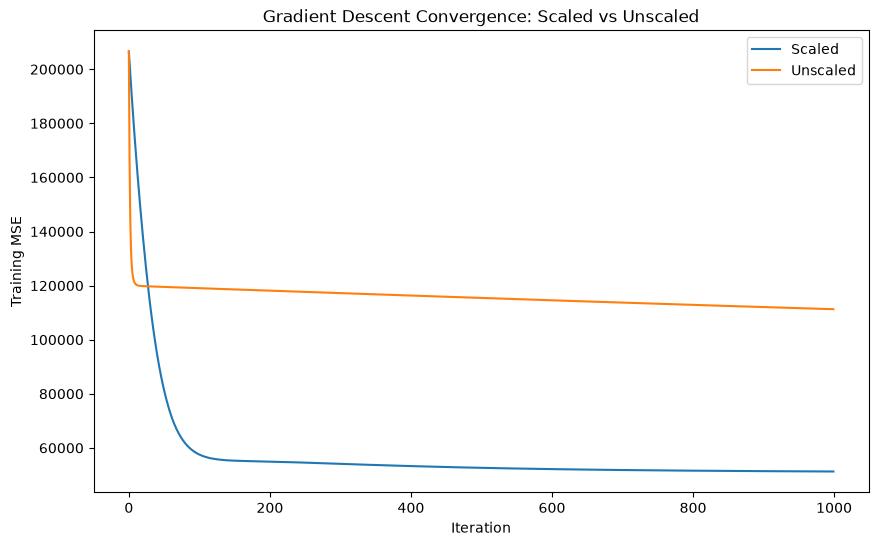

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    scaled_gd.cost_history,
    label="Scaled"
)

plt.plot(
    unscaled_gd.cost_history,
    label="Unscaled"
)

plt.xlabel("Iteration")
plt.ylabel("Training MSE")
plt.title("Gradient Descent Convergence: Scaled vs Unscaled")
plt.legend()

plt.show()

### 8. Evaluation

In [125]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

y_val_pred_scaled = scaled_gd.predict(X_val_scaled_bias)

scaled_rmse = root_mean_squared_error(
    y_val,
    y_val_pred_scaled
)

scaled_mae = mean_absolute_error(
    y_val,
    y_val_pred_scaled
)

scaled_r2 = r2_score(
    y_val,
    y_val_pred_scaled
)


print("Scaled RMSE:", scaled_rmse)
print("Scaled MAE:", scaled_mae)
print("Scaled R²:", scaled_r2)

Scaled RMSE: 69167.77411641047
Scaled MAE: 50258.79004598697
Scaled R²: 0.6344830072442881


In [126]:
y_val_pred_unscaled = unscaled_gd.predict(X_val_unscaled_bias)

unscaled_rmse = root_mean_squared_error(
    y_val,
    y_val_pred_unscaled
)

unscaled_mae = mean_absolute_error(
    y_val,
    unscaled_gd.predict(X_val_unscaled_bias)
)

unscaled_r2 = r2_score(
    y_val,
    unscaled_gd.predict(X_val_unscaled_bias)
)

print("Unscaled RMSE:", unscaled_rmse)
print("Unscaled MAE:", unscaled_mae)
print("Unscaled R²:", unscaled_r2)

Unscaled RMSE: 150295.69927816995
Unscaled MAE: 109323.40434277305
Unscaled R²: -0.7258103887412051


### 9. Effect of learning rate


In [127]:
learning_rates = [
    0.0001,
    0.001,
    0.01,
    0.05,
    0.1
]

In [130]:
learning_rate_results = []

for lr in learning_rates:

    scaled_gd = GradientDescent(learning_rate=lr, n_iterations=1000)
    scaled_gd.fit(X_train_scaled_bias, y_train_pool)

    y_val_pred = scaled_gd.predict(X_val_scaled_bias)

    val_rmse = root_mean_squared_error(
        y_val,
        y_val_pred
    )

    val_mae = mean_absolute_error(
        y_val,
        y_val_pred
    )

    val_r2 = r2_score(
        y_val,
        y_val_pred
    )

    learning_rate_results.append({
        "Learning_Rate": lr,
        "Validation_RMSE": val_rmse,
        "Validation_MAE": val_mae,
        "Validation_R2": val_r2,
        "Final_Training_MSE": scaled_gd.cost_history[-1]
    })

learning_rate_results_df = pd.DataFrame(
    learning_rate_results
)

learning_rate_results_df

,Learning_Rate,Validation_RMSE,Validation_MAE,Validation_R2,Final_Training_MSE
0,0.0001,196693.371750,167183.037925,-1.955830,169155.035115
1,0.0010,81566.738704,56394.068591,0.491693,57637.923702
2,0.0100,69167.774116,50258.790046,0.634483,51268.311506
3,0.0500,68583.485209,50176.123722,0.640632,50955.919616
4,0.1000,68582.557480,50183.002810,0.640642,50960.881554


### 10. Plot all learning curves

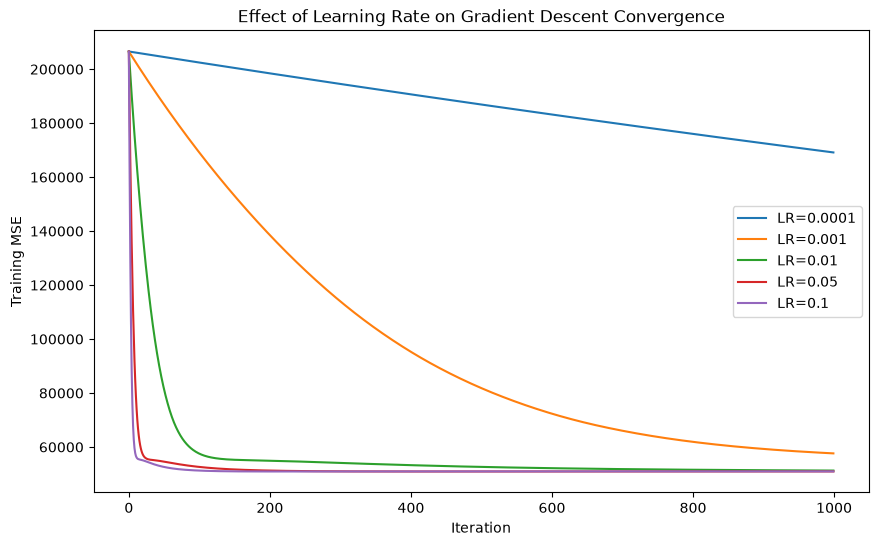

In [131]:
plt.figure(figsize=(10, 6))

for lr in learning_rates:

    scaled_gd = GradientDescent(learning_rate=lr, n_iterations=1000)
    scaled_gd.fit(X_train_scaled_bias, y_train_pool)

    plt.plot(
        scaled_gd.cost_history,
        label=f"LR={lr}"
    )

plt.xlabel("Iteration")
plt.ylabel("Training MSE")
plt.title("Effect of Learning Rate on Gradient Descent Convergence")
plt.legend()

plt.show()

## Conclusion H5A

Feature scaling substantially improved the optimization behavior of
Batch Gradient Descent for Linear Regression. With scaled features,
Gradient Descent converged rapidly and achieved a validation RMSE of
approximately 69,168, compared with 150,296 for the unscaled model.
Validation R² also improved from -0.726 to 0.634.

The convergence curves show that scaling allowed Gradient Descent to
make much larger and more effective parameter updates without becoming
unstable. In contrast, the unscaled features required a much smaller
learning rate and resulted in substantially slower convergence.

However, the scaled and unscaled experiments used different learning
rates, so the performance difference cannot be attributed to feature
scaling alone. Rather, the results demonstrate that feature scaling
substantially improves the practical optimization behavior of Gradient
Descent by making larger learning rates feasible.

## Conclusion of H5B

The learning rate had a substantial effect on the convergence speed and
predictive performance of Batch Gradient Descent.

A very small learning rate of 0.0001 resulted in extremely slow
convergence and poor validation performance, with an RMSE of
approximately 196,693 and an R² of -1.956. Increasing the learning rate
to 0.001 substantially improved performance, while learning rates of
0.01 and above produced much faster convergence.

The learning rates 0.05 and 0.1 achieved the best validation
performance, with nearly identical RMSE values of approximately 68,583
and R² values of approximately 0.641.

Therefore, within the tested range, the results support the hypothesis
that learning rate strongly influences Gradient Descent convergence.
Very small learning rates lead to slow optimization, while an
appropriate learning rate produces faster convergence and better
performance. However, excessively large learning rates were not tested
successfully in this experiment, so divergence or oscillation cannot
yet be concluded from these results.